# Next-Word Prediction: LSTM

Trains the LSTM model on the prepared windows and evaluates it on the held-out test sentences.

Architecture (from the design sketch): `Embedding` -> `LSTM` -> `Dropout` -> `Dense` (linear layer) with `softmax` -> a probability for every word -> the top 5 become the suggestions.

The LSTM keeps a separate cell state `c_t` behind forget, input and output gates, so it can carry information across many steps. See the companion article, *LSTM From First Principles*, for the math.

Metrics: **top-1** and **top-5 accuracy** (is the true next word the first guess / among the five suggestions) and **perplexity** = `exp(cross-entropy)`; lower perplexity means the model is less surprised by the real next word.

## 1. Setup

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

os.environ["EPOCHS"] = "8"
os.environ["UNITS"] = "64"
os.environ["EMBED_DIM"] = "64"
os.environ["BATCH_SIZE"] = "256"
os.environ["SEQ_LEN"] = "5"

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import config

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("TensorFlow:", tf.__version__)
print(f"Epochs={config.EPOCHS}  Units={config.UNITS}  EmbedDim={config.EMBED_DIM}  BatchSize={config.BATCH_SIZE}  SeqLen={config.SEQ_LEN}")

TensorFlow: 2.21.0
Epochs=8  Units=64  EmbedDim=64  BatchSize=256  SeqLen=5


In [2]:
from scripts.build_corpus import build_corpus

sources = {
    name: config.RAW_DIR / name
    for name in ("en_US.blogs.txt", "en_US.news.txt", "en_US.twitter.txt")
}
build_corpus(sources, config.DEFAULT_CORPUS, lines_per_source=15000)

  en_US.blogs.txt: sampled 15,000 lines
  en_US.news.txt: sampled 15,000 lines
  en_US.twitter.txt: sampled 15,000 lines
Wrote 45,000 lines (7.6 MB) to D:\next-word-prediction\data\raw\corpus.txt


WindowsPath('D:/next-word-prediction/data/raw/corpus.txt')

## 2. Train

`src.train.train` is the same code path as `python -m src.train --model lstm`. It uses early stopping on validation loss, halves the learning rate on plateaus, saves the best checkpoint to `models/lstm.keras`, and appends results to `outputs/metrics.json`.

In [3]:
from src.train import train

result = train(
    "lstm",
    config.DEFAULT_CORPUS,
    epochs=8,
    batch_size=256,
    seq_len=5,
    embed_dim=64,
    units=64,
    verbose=2,
)

Data: {"vocab_size": 10000, "train_samples": 986726, "val_samples": 122588, "test_samples": 123465, "seq_len": 5}


Model: "next_word_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_dropout (Dropout)         │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_word_probs (Dense)         │ (None, 10000)          │       650,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,024 (5.05 MB)

 Trainable params: 1,323,024 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
3855/3855 - 176s - 46ms/step - loss: 6.5236 - top1_accuracy: 0.0977 - top5_accuracy: 0.2336 - val_loss: 6.0999 - val_top1_accuracy: 0.1239 - val_top5_accuracy: 0.2696 - learning_rate: 0.0010
Epoch 2/8
3855/3855 - 525s - 136ms/step - loss: 6.1270 - top1_accuracy: 0.1221 - top5_accuracy: 0.2688 - val_loss: 5.9046 - val_top1_accuracy: 0.1342 - val_top5_accuracy: 0.2906 - learning_rate: 0.0010
Epoch 3/8
3855/3855 - 719s - 187ms/step - loss: 5.9710 - top1_accuracy: 0.1306 - top5_accuracy: 0.2846 - val_loss: 5.7965 - val_top1_accuracy: 0.1410 - val_top5_accuracy: 0.3039 - learning_rate: 0.0010
Epoch 4/8
3855/3855 - 268s - 70ms/step - loss: 5.8750 - top1_accuracy: 0.1351 - top5_accuracy: 0.2934 - val_loss: 5.7331 - val_top1_accuracy: 0.1459 - val_top5_accuracy: 0.3113 - learning_rate: 0.0010
Epoch 5/8
3855/3855 - 176s - 46ms/step - loss: 5.8084 - top1_accuracy: 0.1390 - top5_accuracy: 0.2989 - val_loss: 5.6923 - val_top1_accuracy: 0.1491 - val_top5_accuracy: 0.3163 - learning_rate: 

## 3. Training curves

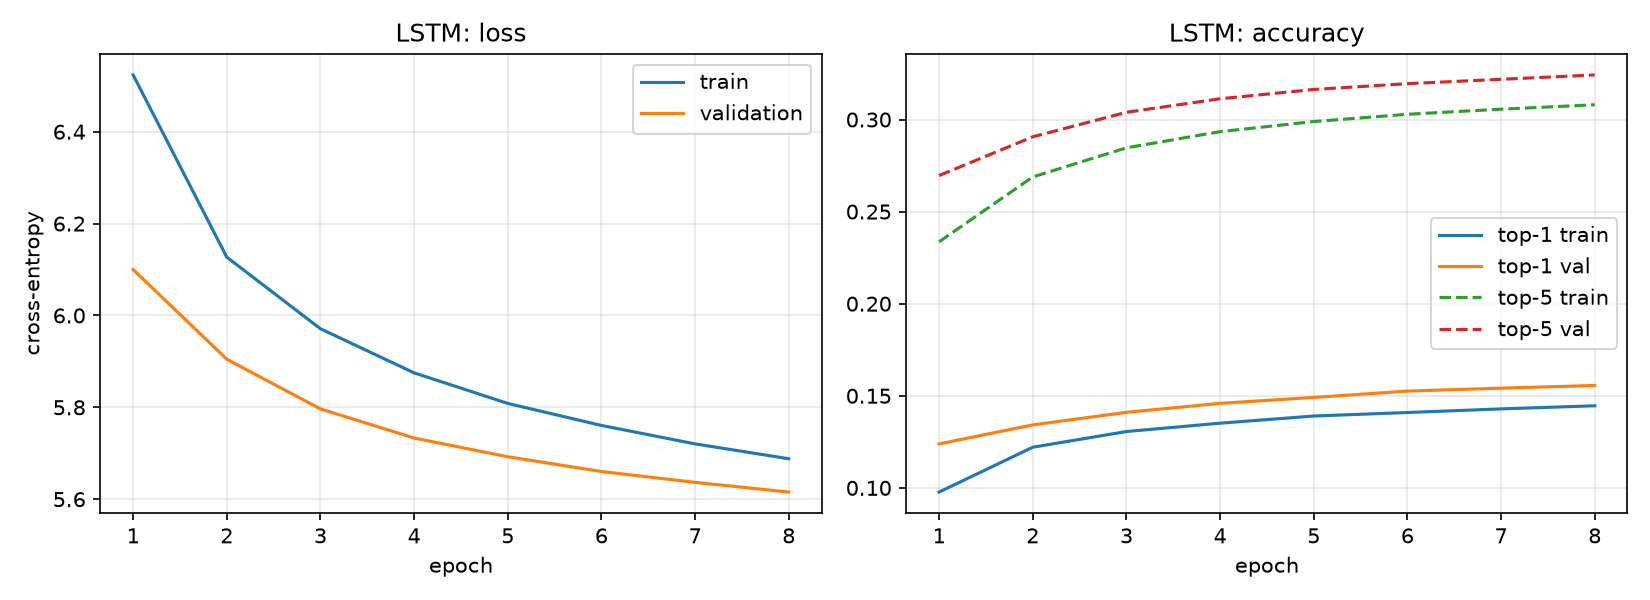

In [4]:
from IPython.display import Image, display

display(Image(filename=str(config.OUTPUTS_DIR / "lstm_training_curves.png")))

## 4. Test-set results

In [5]:
pd.Series({k: v for k, v in result.items() if k != "hyperparameters"})

model               lstm
parameters       1323024
top1_accuracy     0.1552
top5_accuracy     0.3221
test_loss         5.6294
perplexity        278.49
train_seconds     2841.4
epochs_run             8
best_epoch             8
dtype: object

## 5. Try it

Load the saved model exactly as the web app does.

In [6]:
from src.predict import Predictor

predictor = Predictor.load(config.MODELS_DIR / "lstm.keras", config.VOCAB_PATH)

for prompt in ["i want to go to the ", "it is a ", "holmes was ", "what do you "]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(f"{s['word']} ({s['probability']:.0%})" for s in top5))

'i want to go to the '     -> same (1%), first (1%), new (1%), way (1%), world (1%)
'it is a '                 -> lot (3%), little (2%), good (2%), few (2%), bit (2%)
'holmes was '              -> a (11%), the (4%), in (2%), not (2%), an (2%)
'what do you '             -> know (8%), have (8%), want (4%), get (4%), are (4%)


In [7]:
# Mid-word completion, like a keyboard: the last word is unfinished, so we complete it
for prompt in ["i want to g", "it was a very d"]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(s["word"] for s in top5))

'i want to g'              -> get, go, give, grow, gain
'it was a very d'          -> difficult, different, dark, damn, day


In [ ]:
# Probability distribution behind the five suggestions (the last box in the sketch)

%matplotlib inline

prompt = "i want to go to the "
top = predictor.predict_next(prompt, k=10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([s["word"] for s in top][::-1], [s["probability"] for s in top][::-1], color="#3b4fd8")
ax.set(title=f'Top 10 for "{prompt.strip()}"', xlabel="probability")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "lstm_example_prediction.png")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7280\43019850.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Next: `04_gru.ipynb`.